# Multivariate SST denoising

Ahrabian & Mandic, IEEE *Transactions on Signal Processing* 63(9), 2015.
After the same bandwidth tiling as the joint TFR, the **joint
instantaneous amplitude** of each tile is compared to a modified
universal threshold $c\,\hat\sigma\sqrt{2\log N}$ ($c\in[0.1,0.3]$).
Tiles that look like noise are dropped and the rest are inverted
channel-wise.

`SST.denoise` estimates $\hat\sigma$ from the MAD of the finest CWT
scale (MATLAB / Donoho–Johnstone).


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SST, EMD
from pysdkit.data import load_sst_float, load_sst_doppler

plt.rcParams["figure.dpi"] = 120
print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SST())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchrosqueezing Transform (SST)


## 2. Univariate tone in white noise


noisy SNR (dB) 2.1961712818402797
denoised SNR (dB) 2.596576541324068


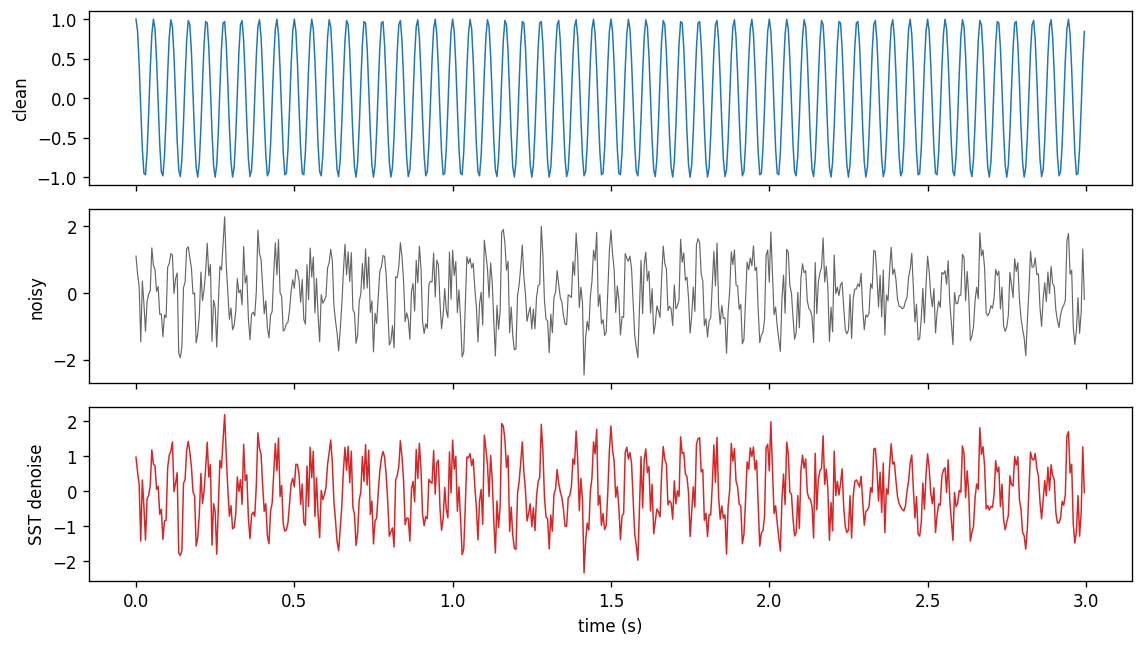

In [2]:
rng = np.random.default_rng(2)
fs = 200.0
t = np.arange(0.0, 3.0, 1.0 / fs)
clean = np.cos(2.0 * np.pi * 18.0 * t)
noisy = clean + 0.55 * rng.standard_normal(t.size)
hat = SST(n_voices=16, n_levels=4, denoise_gain=0.2).denoise(noisy)
print("noisy SNR (dB)", 10 * np.log10(np.sum(clean**2) / np.sum((noisy - clean) ** 2)))
print("denoised SNR (dB)", 10 * np.log10(np.sum(clean**2) / np.sum((hat - clean) ** 2)))

fig, axes = plt.subplots(3, 1, figsize=(9.5, 5.5), sharex=True)
axes[0].plot(t, clean, color="C0", lw=0.9)
axes[0].set_ylabel("clean")
axes[1].plot(t, noisy, color="0.4", lw=0.7)
axes[1].set_ylabel("noisy")
axes[2].plot(t, hat, color="C3", lw=0.9)
axes[2].set_ylabel("SST denoise")
axes[2].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

## 3. Bivariate sinusoids (TSP paper setting)


out shape (2, 600)


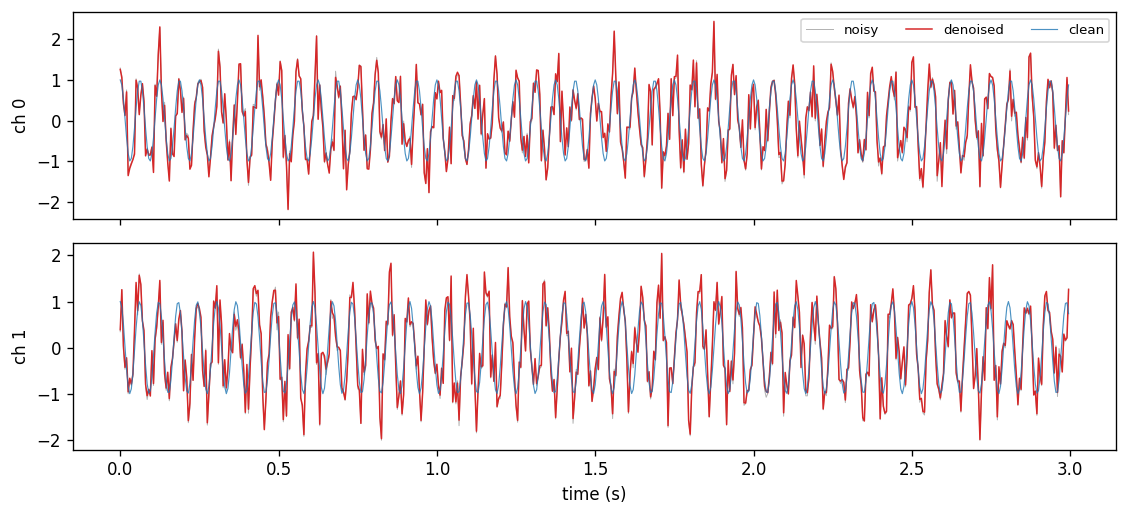

In [3]:
t = np.arange(0.0, 3.0, 1.0 / fs)
clean2 = np.vstack(
    [
        np.cos(2.0 * np.pi * 16.0 * t),
        np.cos(2.0 * np.pi * 16.4 * t),
    ]
)
noisy2 = clean2 + 0.45 * rng.standard_normal(clean2.shape)
hat2 = SST(n_voices=16, n_levels=4, denoise_gain=0.18).denoise(noisy2)
print("out shape", hat2.shape)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.4), sharex=True)
for c in range(2):
    axes[c].plot(t, noisy2[c], color="0.7", lw=0.6, label="noisy")
    axes[c].plot(t, hat2[c], color="C3", lw=0.9, label="denoised")
    axes[c].plot(t, clean2[c], color="C0", lw=0.7, alpha=0.8, label="clean")
    axes[c].set_ylabel(f"ch {c}")
axes[0].legend(loc="upper right", ncol=3, fontsize=8)
axes[1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()